In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix



In [15]:
#1. Load Titanic DataSet
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df= pd.read_csv(url)

print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)
print("\nFirst 5 rows:")
df.head()




Shape: (891, 12)

Missing Values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Data types:
 PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


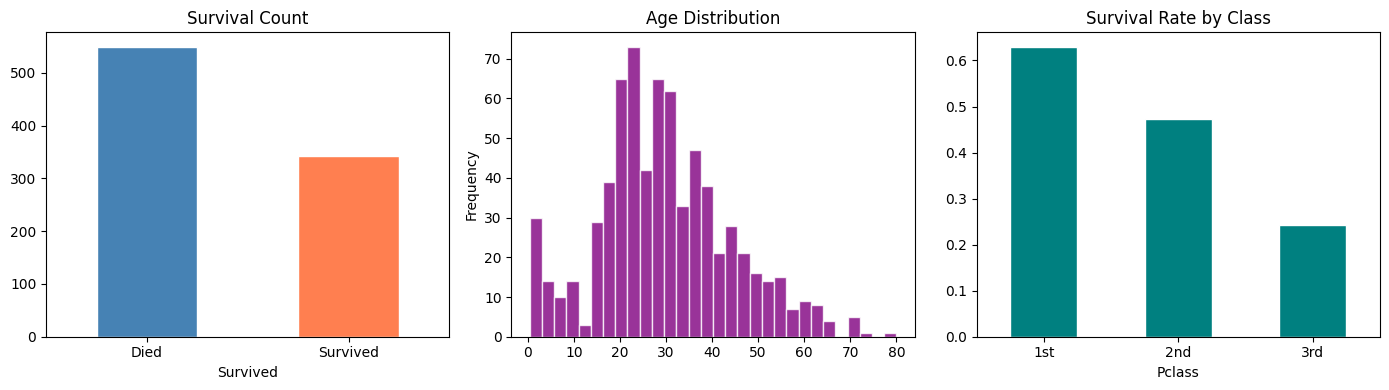

In [16]:
# ── 2. EDA — visualize before cleaning ────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
df['Survived'].value_counts().plot(kind='bar', ax=axes[0],
    color=['steelblue','coral'], edgecolor='white')
axes[0].set_title('Survival Count')
axes[0].set_xticklabels(['Died', 'Survived'], rotation=0)

#Age distribution
df['Age'].dropna().plot(kind='hist', bins=30, ax=axes[1],
    color='purple', edgecolor='white', alpha=0.8)
axes[1].set_title('Age Distribution')

# Survival by class
df.groupby('Pclass')['Survived'].mean().plot(
    kind='bar', ax=axes[2], color='teal', edgecolor='white')
axes[2].set_title('Survival Rate by Class')
axes[2].set_xticklabels(['1st','2nd','3rd'], rotation=0)
plt.tight_layout()
plt.show()



In [4]:
# ── 3. Handle missing values ──────────────────────
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.drop(columns=['Cabin'], inplace=True)   # 77% missing — drop it

print("Missing after cleaning:\n", df.isnull().sum())


Missing after cleaning:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64


C:\Users\rabin\AppData\Local\Temp\ipykernel_26328\18789735.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\rabin\AppData\Local\Temp\ipykernel_26328\18789735.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment u

In [17]:
# ── 4. Feature engineering ────────────────────────
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone']    = (df['FamilySize'] == 1).astype(int)
df['Title']      = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
df['Title']      = df['Title'].replace(
    ['Lady','Countess','Capt','Col','Don','Dr',
     'Major','Rev','Sir','Jonkheer','Dona'], 'Rare')
df['Title']      = df['Title'].replace({'Mlle':'Miss','Ms':'Miss','Mme':'Mrs'})

print("\nNew features — FamilySize sample:\n", df['FamilySize'].value_counts().head())
print("\nTitle counts:\n", df['Title'].value_counts())


New features — FamilySize sample:
 FamilySize
1    537
2    161
3    102
4     29
6     22
Name: count, dtype: int64

Title counts:
 Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


In [18]:
# ── 5. Encode categorical features ────────────────
df['Sex_encoded'] = LabelEncoder().fit_transform(df['Sex'])

embarked_dummies = pd.get_dummies(df['Embarked'], prefix='Embarked')
title_dummies    = pd.get_dummies(df['Title'],    prefix='Title')
df = pd.concat([df, embarked_dummies, title_dummies], axis=1)

In [19]:
# ── 6. Select features & scale ────────────────────
features = ['Pclass','Sex_encoded','Age','Fare','FamilySize',
            'IsAlone','Embarked_C','Embarked_Q','Embarked_S',
            'Title_Master','Title_Miss','Title_Mr','Title_Mrs','Title_Rare']

X = df[features].fillna(0)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)



── Results ──
Accuracy: 0.8045


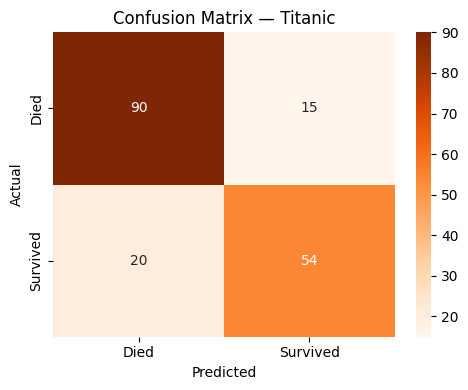

In [20]:
# ── 7. Train & evaluate ───────────────────────────
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("\n── Results ──")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))

plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Died','Survived'],
            yticklabels=['Died','Survived'])
plt.title('Confusion Matrix — Titanic')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

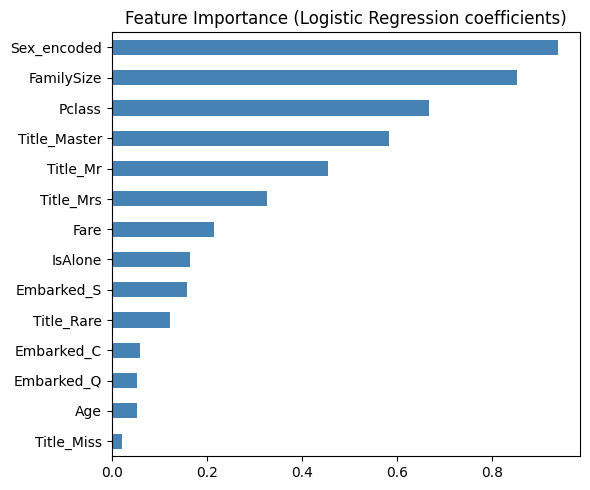

In [21]:
# ── 8. Feature importance ─────────────────────────
coefs = pd.Series(np.abs(model.coef_[0]), index=features).sort_values()
plt.figure(figsize=(6, 5))
coefs.plot(kind='barh', color='steelblue')
plt.title('Feature Importance (Logistic Regression coefficients)')
plt.tight_layout()
plt.show()